In [2]:
#Lanciare questa cella per settare l'inclinazione della telecamera

%run gravity.py

Camera rilevata: Intel RealSense D435I (S/N: 243322072687)
  250 Hz fallito: Couldn't resolve requests
  63 Hz fallito: Couldn't resolve requests
Stream accel avviato (default)
Calibrazione in corso... Tieni la camera FERMA.

Gravita' salvata con successo!
Vettore rilevato: [-0.002 -0.983  0.182]
Ora puoi avviare l'acquisizione.


In [16]:
import subprocess, sys
 
NOME_SESSIONE = "Baseline18"  # Cambia questo nome per ogni sessione di acquisizione
 
proc = subprocess.Popen(
    [sys.executable, "acquisizione.py", NOME_SESSIONE],
    cwd=r"C:\Users\luca2\Desktop\VRula\BodyTracking\separated_scripts"   # <-- cartella del progetto
)
print(f"Acquisizione avviata (PID {proc.pid}) — chiudi la finestra per terminare")
 

Acquisizione avviata (PID 8176) — chiudi la finestra per terminare


In [30]:
import importlib
import warnings, os, sys
warnings.filterwarnings('ignore')
import mediapipe
import sys
import os

print(f"1. Python executable: {sys.executable}")
print(f"2. MediaPipe file: {mediapipe.__file__}")
print(f"3. Cartella di lavoro attuale: {os.getcwd()}")
print(f"4. Contenuto cartella: {os.listdir('.')}")
PROJECT_DIR = r"C:\Users\luca2\Desktop\VRula\BodyTracking\separated_scripts"

os.chdir(PROJECT_DIR)           
sys.path.insert(0, PROJECT_DIR)

print("cwd:", os.getcwd())       

import processing
importlib.reload(processing)
from processing import process_file
 

csv_path = process_file("output_raw/Workload18")  

1. Python executable: c:\Users\luca2\Desktop\VRula\BodyTracking\venv\Scripts\python.exe
2. MediaPipe file: c:\Users\luca2\Desktop\VRula\BodyTracking\venv\Lib\site-packages\mediapipe\__init__.py
3. Cartella di lavoro attuale: C:\Users\luca2\Desktop\VRula\BodyTracking\separated_scripts
4. Contenuto cartella: ['acquisizione.py', 'AnalisiDati.py', 'gravity.py', 'Notebook.ipynb', 'output_analysis', 'output_csv', 'output_raw', 'output_reports', 'output_video', 'processing.py', 'rula_logic.py', 'run_analysis.py', 'SurveyData.csv', 'VRula_Report.html', '__pycache__']
cwd: C:\Users\luca2\Desktop\VRula\BodyTracking\separated_scripts
[PROFILE] balanced  ->  complexity=1  res=640x480  static=False
[LOAD] output_raw/Workload18
       1351 frame  |  durata 62.5s  |  fs~21.6 Hz
[IMU]  gravity caricato da: C:\Users\luca2\Desktop\VRula\BodyTracking\separated_scripts\output_raw\gravity.npy
[IMU]  vettore: [-0.001, -0.983, 0.181]
   99.9%  frame 1350/1351  ok=1350  skip=0
[DONE] 1351 frame processati, 0 

Calcolo DTW traiettorie 3D...
  DTW DX: 0.2536 m  |  DTW SX: 0.2181 m

Tabella salvata in: C:\Users\luca2\Desktop\VRula\BodyTracking\separated_scripts\output_reports\Poste_vs_PosteSX\Poste_vs_PosteSX_Comparazione.csv
                              Metrica       Base   Workload  Variazione %
                 Time to Complete (s)  11.311000   8.241000    -27.141720
      SPARC DX (fluido=meno negativo)  -1.955087  -4.901700   -150.715133
      SPARC SX (fluido=meno negativo)  -8.573191  -1.422764     83.404501
Log-dim Jerk DX (fluido=piu negativo) -19.703196 -20.205218     -2.547919
Log-dim Jerk SX (fluido=piu negativo) -21.481123 -18.520001     13.784766
           Inversioni velocita DX (n)   9.000000  13.000000     44.444444
           Inversioni velocita SX (n)  15.000000   8.000000    -46.666667
               DTW traiettoria DX (m)   0.000000   0.253619           inf
               DTW traiettoria SX (m)   0.000000   0.218060           inf
               Dwell Time DX (% task)  28.6

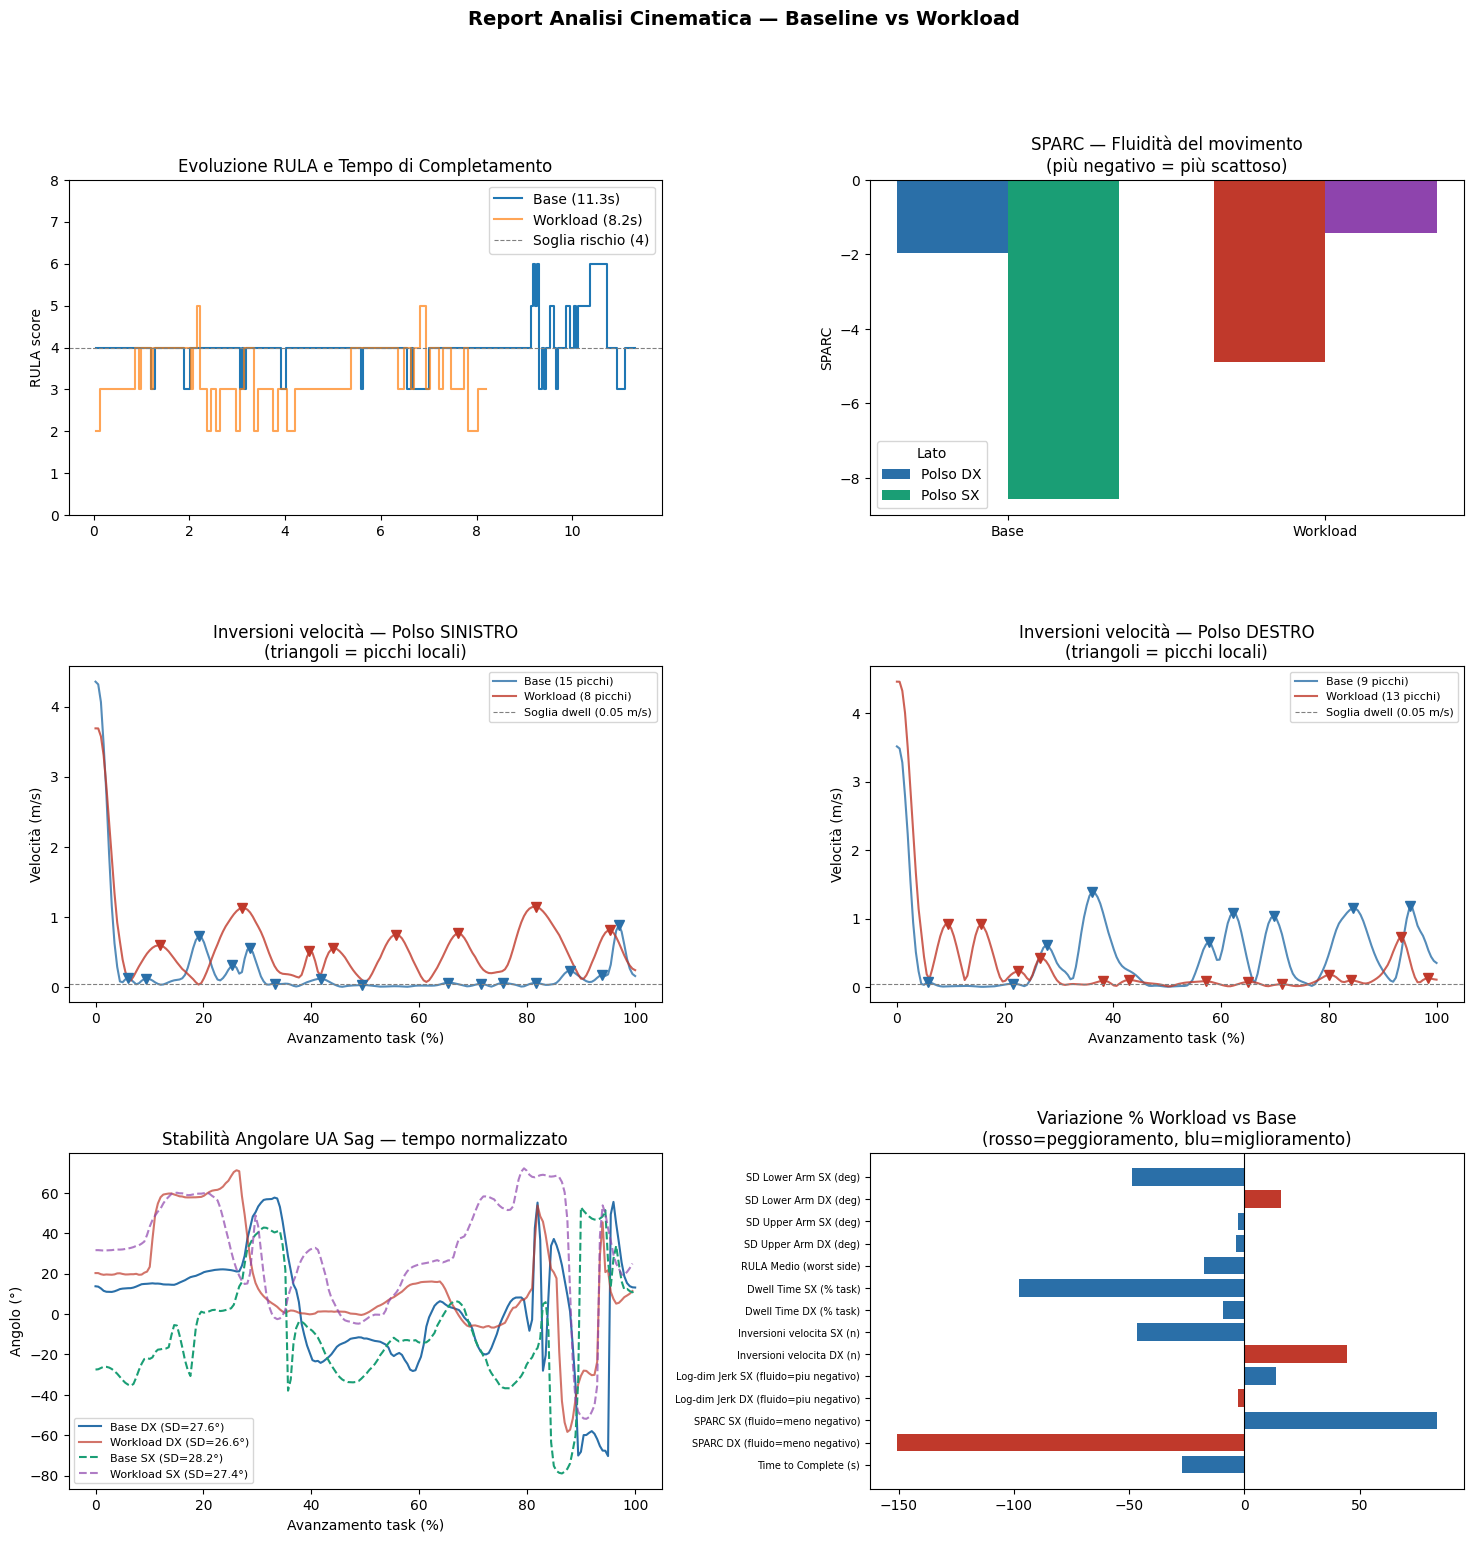

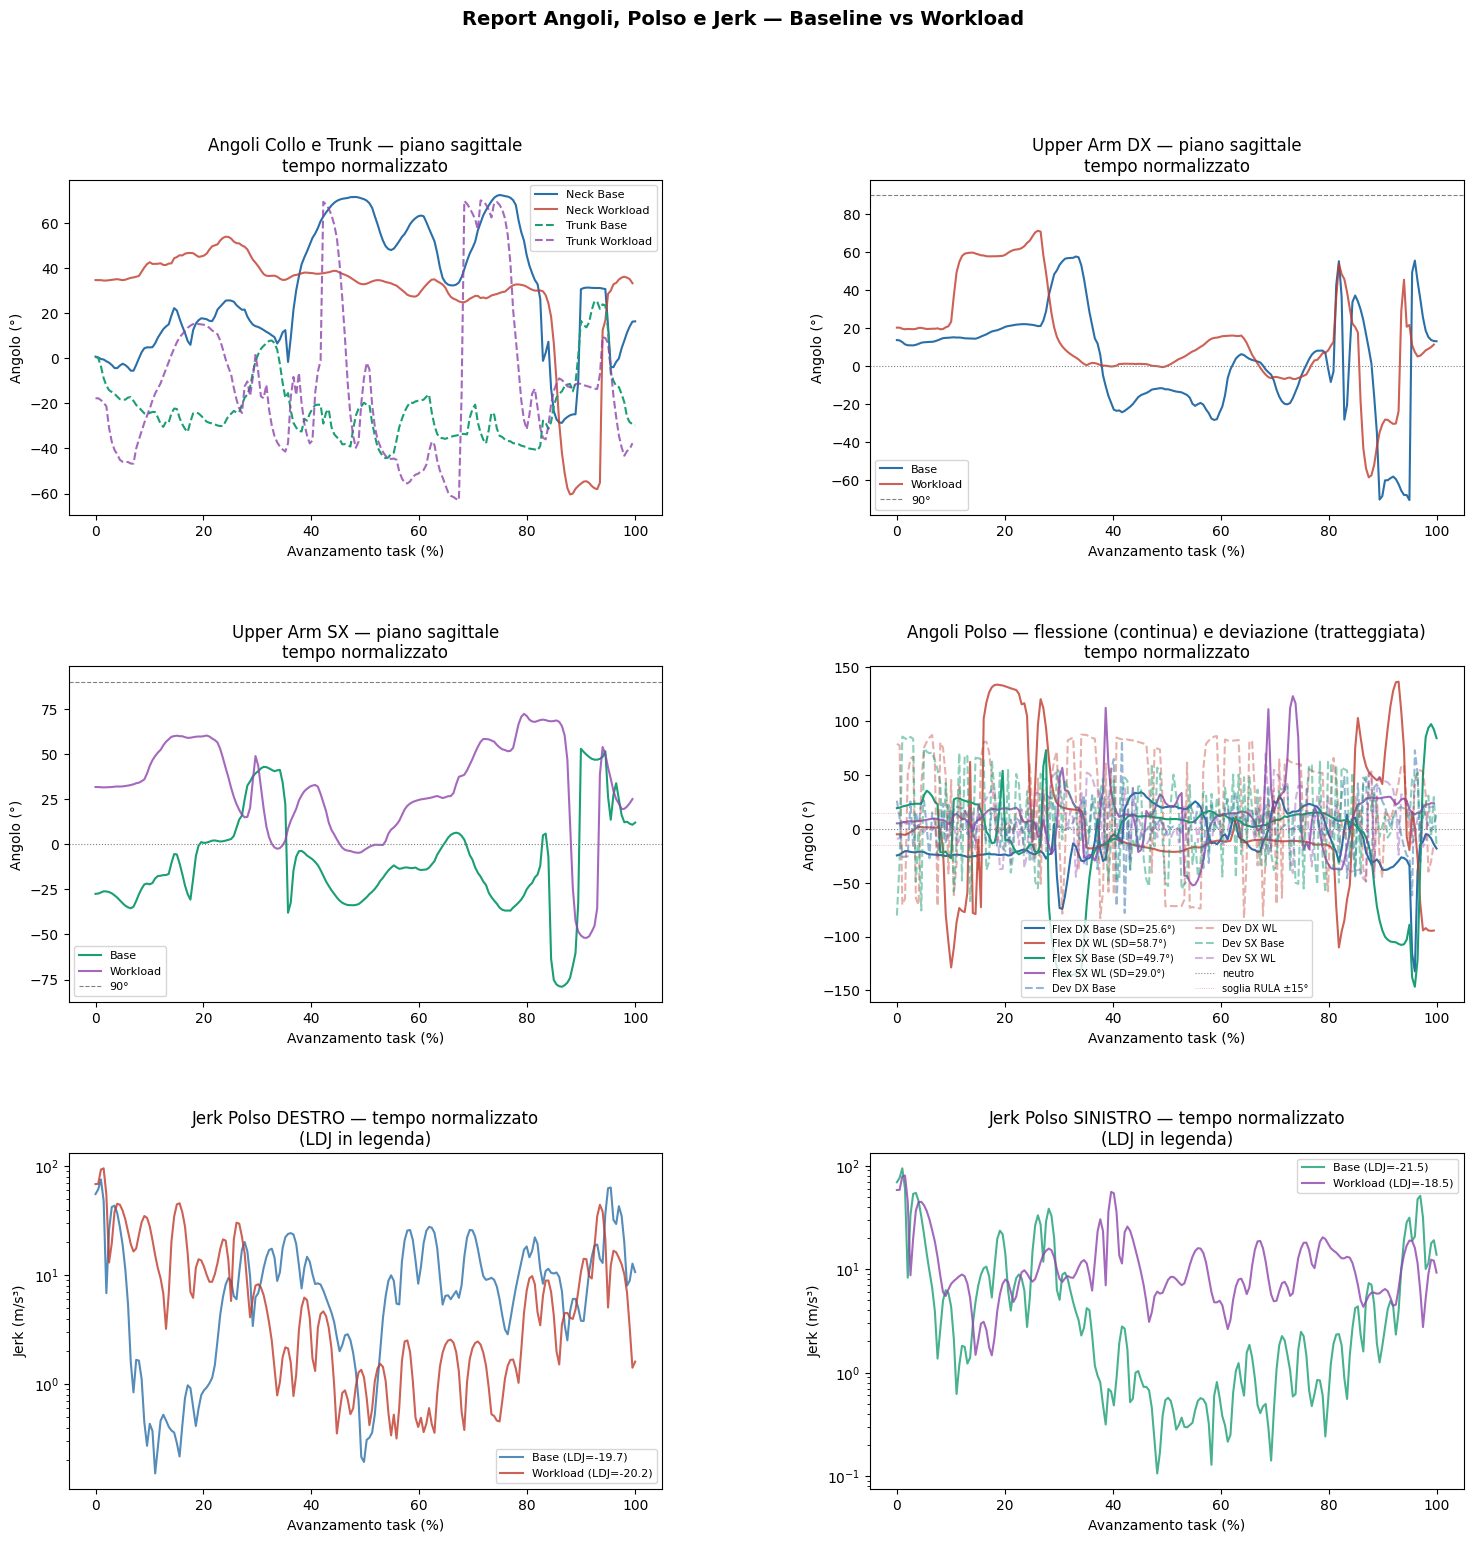

In [4]:
import importlib
import AnalisiDati 
importlib.reload(AnalisiDati)
from AnalisiDati import run_analysis
 
# I CSV ora sono in output_csv/ con il nome del file raw come base
file_base     = "output_csv/Poste.csv"  
file_workload = "output_csv/PosteSX.csv" 
 
results_df, res_b, res_w = run_analysis(file_base, file_workload)

In [4]:
import subprocess, sys

subprocess.run([
    sys.executable, '-m', 'nbconvert',
    '--to', 'html',
    '--no-input',          # nasconde tutto il codice
    '--no-prompt',         # nasconde In[1]: Out[1]:
    '--TagRemovePreprocessor.enabled=True',
    '--TagRemovePreprocessor.remove_cell_tags=log',     # rimuove celle taggate "log"
    '--TagRemovePreprocessor.remove_output_tags=log',   # rimuove output taggati "log"
    'Notebook.ipynb',
    '--output', 'VRula_Report'
], cwd=r"C:\Users\luca2\Desktop\VRula\BodyTracking\separated_scripts")

CompletedProcess(args=['c:\\Users\\luca2\\Desktop\\VRula\\BodyTracking\\venv\\Scripts\\python.exe', '-m', 'nbconvert', '--to', 'html', '--no-input', '--no-prompt', '--TagRemovePreprocessor.enabled=True', '--TagRemovePreprocessor.remove_cell_tags=log', '--TagRemovePreprocessor.remove_output_tags=log', 'Notebook.ipynb', '--output', 'VRula_Report'], returncode=0)

In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# DATASET BUILDER — Sezione 1: Setup e funzioni helper
# ══════════════════════════════════════════════════════════════════════════════
import warnings, os, sys
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks
warnings.filterwarnings('ignore')

PROJECT_DIR = r"C:\Users\luca2\Desktop\VRula\BodyTracking\separated_scripts"
os.chdir(PROJECT_DIR)
sys.path.insert(0, PROJECT_DIR)
os.makedirs('output_analysis', exist_ok=True)

# survey_code -> (csv_number, order_group, dominant_hand)
PARTICIPANTS = {
    2:  ('02', 'B->A', 'DX'),
    1:  ('01', 'A->B', 'SX'),
    3:  ('03', 'B->A', 'DX'),
    4:  ('04', 'A->B', 'DX'),
    5:  ('05', 'B->A', 'DX'),
    6:  ('06', 'A->B', 'DX'),
    7:  ('07', 'B->A', 'DX'),
    8:  ('08', 'B->A', 'DX'),
    9:  ('09', 'A->B', 'SX'),
    10: ('10', 'B->A', 'DX'),
    16: ('11', 'A->B', 'DX'),
}

def _read_csv(path):
    with open(path, 'r', encoding='utf-8-sig') as f:
        first = f.readline()
    sep = ';' if first.count(';') > first.count(',') else ','
    dec = ',' if sep == ';' else '.'
    return pd.read_csv(path, sep=sep, decimal=dec, encoding='utf-8-sig')

def _lowpass(series, b, a):
    return filtfilt(b, a, series.interpolate().ffill().bfill().values)

def _velocity(xf, yf, zf, fs):
    vx = np.gradient(xf, 1/fs); vy = np.gradient(yf, 1/fs); vz = np.gradient(zf, 1/fs)
    return np.sqrt(vx**2 + vy**2 + vz**2)

def _path_length(xf, yf, zf):
    return float(np.sum(np.sqrt(np.diff(xf)**2 + np.diff(yf)**2 + np.diff(zf)**2)))

def _n_peaks(vel, fs):
    peaks, _ = find_peaks(vel, distance=int(0.1 * fs), height=0.03)
    return len(peaks)

print("Setup completato.")


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# DATASET BUILDER — Sezione 2: Funzioni di estrazione metriche
# ══════════════════════════════════════════════════════════════════════════════

def compute_session_metrics(csv_path):
    """Calcola le metriche per-sessione non presenti in _Comparazione.csv."""
    df = _read_csv(csv_path)
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%H:%M:%S.%f')
    df = df.sort_values('Timestamp').reset_index(drop=True)
    df['dt'] = df['Timestamp'].diff().dt.total_seconds()
    df['dt'] = df['dt'].fillna(df['dt'].median()).replace(0, df['dt'].median())
    df['time_cum'] = df['dt'].cumsum()

    fs = 1.0 / df['dt'].median()
    nyq = 0.5 * fs
    b, a = butter(2, min(1.5, nyq * 0.8) / nyq, btype='low')

    xR = _lowpass(df['R_Wrist_X'], b, a); yR = _lowpass(df['R_Wrist_Y'], b, a); zR = _lowpass(df['R_Wrist_Z'], b, a)
    xL = _lowpass(df['L_Wrist_X'], b, a); yL = _lowpass(df['L_Wrist_Y'], b, a); zL = _lowpass(df['L_Wrist_Z'], b, a)

    vel_R    = _velocity(xR, yR, zR, fs)
    vel_L    = _velocity(xL, yL, zL, fs)
    path_R   = _path_length(xR, yR, zR)
    path_L   = _path_length(xL, yL, zL)
    n_pk_R   = _n_peaks(vel_R, fs)
    n_pk_L   = _n_peaks(vel_L, fs)

    g  = lambda col: float(df[col].mean()) if col in df.columns else float('nan')
    gs = lambda col: float(df[col].std())  if col in df.columns else float('nan')
    ua_col_R = next((c for c in ['UA_Sag_R', 'UA_Ang_R'] if c in df.columns), None)
    ua_col_L = next((c for c in ['UA_Sag_L', 'UA_Ang_L'] if c in df.columns), None)

    return {
        'Vel_Mean_DX': float(np.mean(vel_R)),  'Vel_Mean_SX': float(np.mean(vel_L)),
        'Vel_Peak_DX': float(np.max(vel_R)),   'Vel_Peak_SX': float(np.max(vel_L)),
        'Vel_SD_DX':   float(np.std(vel_R)),   'Vel_SD_SX':   float(np.std(vel_L)),
        'PathLen_DX':  path_R,                  'PathLen_SX':  path_L,
        'PathEff_DX':  (n_pk_R * 0.5) / path_R if path_R > 0 else float('nan'),
        'PathEff_SX':  (n_pk_L * 0.5) / path_L if path_L > 0 else float('nan'),
        'RULA_Peak':   float(df['RULA_C'].max()),
        'RULA_Pct4':   float((df['RULA_C'] >= 4).mean() * 100),
        'RULA_Pct6':   float((df['RULA_C'] >= 6).mean() * 100),
        'Wr_Flex_Mean_DX': g('Wr_Flex_R'), 'Wr_Flex_SD_DX': gs('Wr_Flex_R'),
        'Wr_Dev_Mean_DX':  g('Wr_Dev_R'),  'Wr_Dev_SD_DX':  gs('Wr_Dev_R'),
        'Wr_Flex_Mean_SX': g('Wr_Flex_L'), 'Wr_Flex_SD_SX': gs('Wr_Flex_L'),
        'Wr_Dev_Mean_SX':  g('Wr_Dev_L'),  'Wr_Dev_SD_SX':  gs('Wr_Dev_L'),
        'UA_Mean_DX':      g(ua_col_R),    'UA_Mean_SX':    g(ua_col_L),
        'Neck_Sag_Mean':   g('Neck_Sag'),  'Neck_Sag_SD':   gs('Neck_Sag'),
        'Trunk_Sag_Mean':  g('Trunk_Sag'), 'Trunk_Sag_SD':  gs('Trunk_Sag'),
    }


def load_comparazione(csv_num, condition):
    """Estrae le metriche già presenti in _Comparazione.csv per una singola sessione."""
    pair = f'Baseline{csv_num}_vs_Workload{csv_num}'
    path = f'output_reports/{pair}/{pair}_Comparazione.csv'
    df   = pd.read_csv(path)
    col  = 'Base' if condition == 'baseline' else 'Workload'
    m    = dict(zip(df['Metrica'], df[col]))
    return {
        'Time_to_Complete': m.get('Time to Complete (s)'),
        'SPARC_DX':  m.get('SPARC DX (fluido=meno negativo)'),
        'SPARC_SX':  m.get('SPARC SX (fluido=meno negativo)'),
        'Jerk_DX':   m.get('Log-dim Jerk DX (fluido=piu negativo)'),
        'Jerk_SX':   m.get('Log-dim Jerk SX (fluido=piu negativo)'),
        'VelInv_DX': m.get('Inversioni velocita DX (n)'),
        'VelInv_SX': m.get('Inversioni velocita SX (n)'),
        'DTW_DX':    m.get('DTW traiettoria DX (m)'),
        'DTW_SX':    m.get('DTW traiettoria SX (m)'),
        'Dwell_DX':  m.get('Dwell Time DX (% task)'),
        'Dwell_SX':  m.get('Dwell Time SX (% task)'),
        'RULA_Mean': m.get('RULA Medio (worst side)'),
        'SD_UA_DX':  m.get('SD Upper Arm DX (deg)'),
        'SD_UA_SX':  m.get('SD Upper Arm SX (deg)'),
        'SD_LA_DX':  m.get('SD Lower Arm DX (deg)'),
        'SD_LA_SX':  m.get('SD Lower Arm SX (deg)'),
    }


def build_survey_domains(survey_path='SurveyData.csv'):
    """
    Costruisce i 4 domini soggettivi normalizzati da SurveyData.csv.
    Tutti i valori sono già in scala 0-1.
    Direzione domini: NASA e SART → alto = più carico/burden.
    AgencyControl → alto = più controllo (meno burden).
    """
    df = pd.read_csv(survey_path, sep=';', decimal=',', encoding='utf-8-sig')
    df.columns = df.columns.str.strip()

    # Tieni solo le 22 righe dati (escludi righe aggregate in fondo)
    df = df[pd.to_numeric(df['Participant code'], errors='coerce').notna()].copy()
    df['Participant code'] = df['Participant code'].astype(float).astype(int)
    df['Condition'] = df['Condition'].str.strip().str.lower()

    num_cols = df.columns.drop(['Participant code', 'Condition'])
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    # NASA domain: mental demand, time pressure, effort, performance (rev), frustration
    emo = ['NASA-emotional experience-Insecurity', 'NASA-emotional experience-Discouragement',
           'NASA-emotional experience-Irritation',  'NASA-emotional experience-Stress',
           'NASA-emotional experience-Annoyement']
    df['_nasa_frustration']   = df[emo].mean(axis=1)
    df['_nasa_perf_rev']      = 1 - df['NASA-perceived performance1']
    df['NASA_domain'] = df[['NASA-Perceived mental demand 1', 'NASA-perceived time pressure1',
                              'NASA_effort required1', '_nasa_perf_rev',
                              '_nasa_frustration']].mean(axis=1)

    # SART domain: complexity (direct), readiness/alertness (rev), attentional focus (rev), spare capacity (rev)
    # → alto = più burden
    df['SART_domain'] = pd.DataFrame({
        'complexity':   df['SART-perceived task complexity'],
        'readiness':    1 - df['SART-readiness / alertness'],
        'attention':    1 - df['SART-attentional focus on movement'],
        'spare':        1 - df['SART-spare mental capacity'],
    }).mean(axis=1)

    # Agency+Control domain: alto = più controllo
    df['AgencyControl_domain'] = df[['Perceived control&stress-perceived control of movements',
                                      'Sense of agency']].mean(axis=1)

    # Error Awareness: item singolo
    df['Error_Awareness'] = df['Perceived control&stress-awareness of mistakes or near-mistakes']

    return df[['Participant code', 'Condition',
               'NASA_domain', 'SART_domain', 'AgencyControl_domain', 'Error_Awareness']]


print("Funzioni definite.")


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# DATASET BUILDER — Sezione 3: Build per-session + merge + remapping + salvataggio
# ══════════════════════════════════════════════════════════════════════════════

# ─── 1. Calcola metriche per ogni sessione ───────────────────────────────────
per_session_rows = []

for survey_code, (csv_num, order_group, dom_hand) in sorted(PARTICIPANTS.items(), key=lambda x: x[1][0]):
    for condition in ['baseline', 'workload']:
        prefix = 'Baseline' if condition == 'baseline' else 'Workload'
        csv_path = f'output_csv/{prefix}{csv_num}.csv'
        print(f"  {prefix}{csv_num} ... ", end='', flush=True)

        sess = compute_session_metrics(csv_path)
        comp = load_comparazione(csv_num, condition)

        row = {
            'Subject_ID':  int(csv_num),
            'Survey_Code': survey_code,
            'Condition':   condition,
            'Order_Group': order_group,
            'Dom_Hand':    dom_hand,
        }
        row.update(comp)
        row.update(sess)
        per_session_rows.append(row)
        print('OK')

df_all = pd.DataFrame(per_session_rows)
print(f"\nSessioni processate: {len(df_all)}")

# ─── 2. Salva i CSV per-sessione in output_analysis/ ────────────────────────
for _, r in df_all.iterrows():
    prefix = 'Baseline' if r['Condition'] == 'baseline' else 'Workload'
    fname  = f"output_analysis/{prefix}{r['Subject_ID']:02d}_metrics.csv"
    pd.DataFrame([r]).to_csv(fname, index=False)

print("CSV per-sessione salvati in output_analysis/")

# ─── 3. Merge con dati soggettivi ────────────────────────────────────────────
survey = build_survey_domains('SurveyData.csv')
df_all = df_all.merge(
    survey.rename(columns={'Participant code': 'Survey_Code'}),
    on=['Survey_Code', 'Condition'],
    how='left'
)

missing_survey = df_all['NASA_domain'].isna().sum()
if missing_survey > 0:
    print(f"ATTENZIONE: {missing_survey} righe senza dati survey — controlla Survey_Code e Condition")

# ─── 4. Remapping DX/SX → Dom/NonDom ────────────────────────────────────────
# Identifica tutte le colonne con coppia _DX / _SX
base_cols = sorted({c.replace('_DX', '') for c in df_all.columns
                    if c.endswith('_DX') and c.replace('_DX', '') + '_SX' in df_all.columns})

# Swap per i mancini (Dom_Hand == 'SX')
left_mask = df_all['Dom_Hand'] == 'SX'
for base in base_cols:
    dx, sx = f'{base}_DX', f'{base}_SX'
    df_all.loc[left_mask, [dx, sx]] = df_all.loc[left_mask, [sx, dx]].values

# Rinomina _DX → _Dom, _SX → _NonDom
rename_map = {f'{b}_DX': f'{b}_Dom' for b in base_cols}
rename_map.update({f'{b}_SX': f'{b}_NonDom' for b in base_cols})
df_all = df_all.rename(columns=rename_map)

# ─── 5. Salva il dataset unico ───────────────────────────────────────────────
out_path = 'output_analysis/analysis_dataset.csv'
df_all = df_all.sort_values(['Subject_ID', 'Condition']).reset_index(drop=True)
df_all.to_csv(out_path, index=False)

print(f"\nDataset salvato: {out_path}")
print(f"Shape: {df_all.shape[0]} righe × {df_all.shape[1]} colonne")
print("\nAnteprima colonne:")
print([c for c in df_all.columns])
print("\nCheck survey merge:")
print(df_all[['Subject_ID', 'Condition', 'Order_Group', 'Dom_Hand',
              'RULA_Mean', 'NASA_domain', 'SART_domain']].to_string(index=False))


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# ANALISI STATISTICA — Sezione 0: Import e preparazione dataset
# ══════════════════════════════════════════════════════════════════════════════
import warnings, os
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import wilcoxon, shapiro, spearmanr
from scipy.stats import rankdata
from statsmodels.stats.multitest import multipletests
warnings.filterwarnings('ignore')

os.makedirs('output_analysis/figures', exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

df    = pd.read_csv('output_analysis/analysis_dataset.csv')
df_b  = df[df['Condition'] == 'baseline'].sort_values('Subject_ID').reset_index(drop=True)
df_wl = df[df['Condition'] == 'workload' ].sort_values('Subject_ID').reset_index(drop=True)

ID_COLS = ['Subject_ID', 'Survey_Code', 'Condition', 'Order_Group', 'Dom_Hand']
METRIC_COLS = [c for c in df.columns if c not in ID_COLS]

df_delta = df_b[['Subject_ID', 'Order_Group', 'Dom_Hand']].copy()
for c in METRIC_COLS:
    if df[c].dtype != object:
        df_delta[f'd_{c}'] = df_wl[c].values - df_b[c].values

N = len(df_b)
print(f"N = {N}  |  dataset {df.shape}  |  delta {df_delta.shape}")

# ─── Helper: Wilcoxon signed-rank con r_rb ────────────────────────────────────
def do_wilcoxon(b_arr, wl_arr, label=''):
    b, w = np.asarray(b_arr, float), np.asarray(wl_arr, float)
    diff = w - b
    diff_nz = diff[diff != 0]
    n_nz = len(diff_nz)
    if n_nz < 4:
        return dict(label=label, n=n_nz, median_b=np.median(b), median_wl=np.median(w),
                    delta_med=np.median(diff), W=np.nan, p=np.nan, r_rb=np.nan)
    W, p = wilcoxon(w, b, alternative='two-sided')
    ranks = rankdata(np.abs(diff_nz))
    T_plus  = float(np.sum(ranks[diff_nz > 0]))
    T_minus = float(np.sum(ranks[diff_nz < 0]))
    r_rb    = (T_plus - T_minus) / (n_nz * (n_nz + 1) / 2)
    return dict(label=label, n=N, median_b=np.median(b), median_wl=np.median(w),
                delta_med=np.median(diff), W=W, p=p, r_rb=r_rb)

# ─── Helper: Bootstrap Spearman CI ───────────────────────────────────────────
def spearman_boot_ci(x, y, n_boot=1000, ci=95):
    x, y = np.asarray(x, float), np.asarray(y, float)
    mask  = np.isfinite(x) & np.isfinite(y)
    x, y  = x[mask], y[mask]
    rho0, p0 = spearmanr(x, y)
    rhos = []
    rng  = np.random.default_rng(42)
    for _ in range(n_boot):
        idx   = rng.integers(0, len(x), size=len(x))
        rhos.append(spearmanr(x[idx], y[idx])[0])
    lo, hi = np.percentile(rhos, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return rho0, p0, lo, hi

key_deltas = [c for c in ['d_RULA_Mean','d_Jerk_Dom','d_SPARC_Dom','d_Dwell_Dom',
                           'd_Vel_Mean_Dom','d_PathEff_Dom','d_NASA_domain','d_SART_domain',
                           'd_AgencyControl_domain'] if c in df_delta.columns]
print("\nDelta scores (WL - Base) per le metriche chiave:")
print(df_delta[['Subject_ID'] + key_deltas].round(4).to_string(index=False))


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# ANALISI STATISTICA — Sezione 1: Statistiche descrittive
# ══════════════════════════════════════════════════════════════════════════════

ALL_METRICS = {
    # label: (col, expected_direction_wl_vs_base)
    'SPARC Dom':      ('SPARC_Dom',     'decrease'),
    'SPARC NonDom':   ('SPARC_NonDom',  'decrease'),
    'Jerk Dom':       ('Jerk_Dom',      'increase'),
    'Jerk NonDom':    ('Jerk_NonDom',   'increase'),
    'VelInv Dom':     ('VelInv_Dom',    'increase'),
    'VelInv NonDom':  ('VelInv_NonDom', 'increase'),
    'Dwell Dom (%)':  ('Dwell_Dom',     'increase'),
    'Dwell NonDom (%)':('Dwell_NonDom', 'increase'),
    'DTW Dom (m)':    ('DTW_Dom',       'increase'),
    'DTW NonDom (m)': ('DTW_NonDom',    'increase'),
    'RULA Mean':      ('RULA_Mean',     'increase'),
    'RULA Peak':      ('RULA_Peak',     'increase'),
    'RULA %>=4':      ('RULA_Pct4',     'increase'),
    'RULA %>=6':      ('RULA_Pct6',     'increase'),
    'SD UA Dom':      ('SD_UA_Dom',     'decrease'),
    'SD UA NonDom':   ('SD_UA_NonDom',  'decrease'),
    'SD LA Dom':      ('SD_LA_Dom',     'decrease'),
    'SD LA NonDom':   ('SD_LA_NonDom',  'decrease'),
    'Vel Mean Dom':   ('Vel_Mean_Dom',  'decrease'),
    'Vel Mean NonDom':('Vel_Mean_NonDom','decrease'),
    'PathEff Dom':    ('PathEff_Dom',   'decrease'),
    'PathEff NonDom': ('PathEff_NonDom','decrease'),
    'Time to Complete': ('Time_to_Complete', 'increase'),
    'NASA domain':    ('NASA_domain',   'increase'),
    'SART domain':    ('SART_domain',   'increase'),
    'AgencyControl':  ('AgencyControl_domain', 'decrease'),
    'Error Awareness':('Error_Awareness','increase'),
}

rows = []
for label, (col, _) in ALL_METRICS.items():
    if col not in df.columns:
        continue
    b_vals  = df_b[col].dropna().values
    wl_vals = df_wl[col].dropna().values
    rows.append({
        'Metrica':        label,
        'Med_Base':       round(np.median(b_vals), 4),
        'IQR_Base':       f"[{round(np.percentile(b_vals, 25),3)}, {round(np.percentile(b_vals, 75),3)}]",
        'Mean_Base±SD':   f"{round(np.mean(b_vals),3)} ± {round(np.std(b_vals),3)}",
        'Med_WL':         round(np.median(wl_vals), 4),
        'IQR_WL':         f"[{round(np.percentile(wl_vals, 25),3)}, {round(np.percentile(wl_vals, 75),3)}]",
        'Mean_WL±SD':     f"{round(np.mean(wl_vals),3)} ± {round(np.std(wl_vals),3)}",
    })

desc_df = pd.DataFrame(rows)
desc_df.to_csv('output_analysis/descriptive_stats.csv', index=False)
print("Statistiche descrittive — Mediana [IQR], Media ± DS")
print(desc_df.to_string(index=False))


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# ANALISI STATISTICA — Sezione 2: Normalità (Shapiro-Wilk sui delta scores)
# ══════════════════════════════════════════════════════════════════════════════

norm_rows = []
PRIMARY_COLS = ['SPARC_Dom', 'SPARC_NonDom', 'Jerk_Dom', 'Jerk_NonDom',
                'VelInv_Dom', 'VelInv_NonDom', 'Dwell_Dom', 'Dwell_NonDom',
                'DTW_Dom', 'RULA_Mean', 'RULA_Pct4', 'SD_UA_Dom', 'SD_LA_Dom',
                'Vel_Mean_Dom', 'PathEff_Dom',
                'NASA_domain', 'SART_domain', 'AgencyControl_domain', 'Error_Awareness']
PRIMARY_COLS = [c for c in PRIMARY_COLS if f'd_{c}' in df_delta.columns]

for col in PRIMARY_COLS:
    d = df_delta[f'd_{col}'].dropna().values
    if len(d) < 3:
        continue
    W_sw, p_sw = shapiro(d)
    norm_rows.append({'Metrica': col, 'W': round(W_sw, 4), 'p_shapiro': round(p_sw, 4),
                      'Normale (p>0.05)': 'Si' if p_sw > 0.05 else 'No'})

norm_df = pd.DataFrame(norm_rows)
norm_df.to_csv('output_analysis/normality_tests.csv', index=False)
print("Shapiro-Wilk sui delta scores (WL - Base)")
print(norm_df.to_string(index=False))

# Q-Q plots per le variabili primarie
ncols = 5
nrows = int(np.ceil(len(PRIMARY_COLS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 3), tight_layout=True)
axes = np.array(axes).flatten()
for i, col in enumerate(PRIMARY_COLS):
    ax = axes[i]
    d  = df_delta[f'd_{col}'].dropna().values
    (osm, osr), (slope, intercept, _) = stats.probplot(d, dist='norm')
    ax.scatter(osm, osr, s=30, color='steelblue', zorder=3)
    x_line = np.array([osm.min(), osm.max()])
    ax.plot(x_line, slope * x_line + intercept, 'r--', lw=1.2)
    p_val = norm_df[norm_df['Metrica'] == col]['p_shapiro'].values
    p_str = f"p={p_val[0]:.3f}" if len(p_val) else ''
    ax.set_title(f"{col.replace('_',' ')}\n{p_str}", fontsize=8)
    ax.set_xlabel('Theoretical quantiles', fontsize=7)
    ax.set_ylabel('Sample quantiles', fontsize=7)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Q-Q plots — delta scores (WL − Base)', fontsize=11, y=1.01)
fig.savefig('output_analysis/figures/qq_plots.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure salvata: output_analysis/figures/qq_plots.png")


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# ANALISI STATISTICA — Sezione 3: Wilcoxon Signed-Rank + BH FDR
# ══════════════════════════════════════════════════════════════════════════════

# ─── Famiglia A: outcome primari oggettivi ────────────────────────────────────
OBJ_METRICS = [
    ('SPARC Dom',       'SPARC_Dom',      'decrease'),
    ('SPARC NonDom',    'SPARC_NonDom',   'decrease'),
    ('Jerk Dom',        'Jerk_Dom',       'increase'),
    ('Jerk NonDom',     'Jerk_NonDom',    'increase'),
    ('VelInv Dom',      'VelInv_Dom',     'increase'),
    ('VelInv NonDom',   'VelInv_NonDom',  'increase'),
    ('Dwell Dom (%)',   'Dwell_Dom',      'increase'),
    ('Dwell NonDom (%)', 'Dwell_NonDom',  'increase'),
    ('RULA Mean',       'RULA_Mean',      'increase'),
    ('RULA %>=4',       'RULA_Pct4',      'increase'),
    ('SD UA Dom',       'SD_UA_Dom',      'decrease'),
    ('SD LA Dom',       'SD_LA_Dom',      'decrease'),
    ('Vel Mean Dom',    'Vel_Mean_Dom',   'decrease'),
    ('PathEff Dom',     'PathEff_Dom',    'decrease'),
    ('Time to Complete','Time_to_Complete','increase'),
]
OBJ_METRICS = [(l, c, d) for l, c, d in OBJ_METRICS if c in df.columns]

# ─── Famiglia B: outcome secondari soggettivi ─────────────────────────────────
SUBJ_METRICS = [
    ('NASA domain',    'NASA_domain',          'increase'),
    ('SART domain',    'SART_domain',           'increase'),
    ('AgencyControl',  'AgencyControl_domain',  'decrease'),
    ('Error Awareness','Error_Awareness',        'increase'),
]
SUBJ_METRICS = [(l, c, d) for l, c, d in SUBJ_METRICS if c in df.columns]

def run_family(metric_list, family_name):
    results = []
    for label, col, direction in metric_list:
        r = do_wilcoxon(df_b[col].values, df_wl[col].values, label=label)
        r['expected'] = direction
        r['direction_ok'] = (
            (direction == 'increase' and r['delta_med'] > 0) or
            (direction == 'decrease' and r['delta_med'] < 0)
            if not np.isnan(r['delta_med']) else None
        )
        results.append(r)
    res_df = pd.DataFrame(results)
    # BH FDR correction on valid p-values
    valid = res_df['p'].notna()
    if valid.sum() > 1:
        reject, q_vals, _, _ = multipletests(res_df.loc[valid, 'p'], method='fdr_bh')
        res_df.loc[valid, 'q_BH'] = q_vals
        res_df.loc[valid, 'reject_BH'] = reject
    res_df['q_BH']     = res_df.get('q_BH', np.nan)
    res_df['reject_BH']= res_df.get('reject_BH', False)
    res_df.to_csv(f'output_analysis/wilcoxon_{family_name}.csv', index=False)

    print(f"\n=== Famiglia {family_name.upper()} (N={N}) ===")
    print(f"{'Metrica':<22} {'Med_B':>8} {'Med_WL':>8} {'Δ_med':>8} {'W':>6} "
          f"{'p':>7} {'q_BH':>7} {'r_rb':>7} {'Dir OK':>7}")
    print('-' * 90)
    for _, row in res_df.iterrows():
        p_str  = f"{row['p']:.4f}" if pd.notna(row['p']) else '  n/a '
        q_str  = f"{row['q_BH']:.4f}" if pd.notna(row.get('q_BH')) else '  n/a '
        sig_q  = ' *' if row.get('reject_BH', False) else '  '
        dir_ok = 'YES' if row.get('direction_ok') else ('NO' if row.get('direction_ok') is False else '?')
        print(f"{row['label']:<22} {row['median_b']:>8.4f} {row['median_wl']:>8.4f} "
              f"{row['delta_med']:>8.4f} {row['W']:>6.1f} {p_str:>7} {q_str+sig_q:>9} "
              f"{row['r_rb']:>7.3f} {dir_ok:>7}")
    return res_df

res_obj  = run_family(OBJ_METRICS,  'obiettivi')
res_subj = run_family(SUBJ_METRICS, 'soggettivi')


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# ANALISI STATISTICA — Sezione 4: Correlazioni Spearman (delta scores) + bootstrap CI
# ══════════════════════════════════════════════════════════════════════════════

CORR_PAIRS = [
    # (label, delta_subj_col, delta_obj_col, razionale)
    ('NASA vs Jerk Dom',       'd_NASA_domain',         'd_Jerk_Dom',        'cognitive WL -> less smooth?'),
    ('NASA vs SPARC Dom',      'd_NASA_domain',         'd_SPARC_Dom',       'spectral fluidity'),
    ('NASA vs Dwell Dom',      'd_NASA_domain',         'd_Dwell_Dom',       'WL -> more hesitation?'),
    ('NASA vs RULA Mean',      'd_NASA_domain',         'd_RULA_Mean',       'WL -> worse posture?'),
    ('NASA vs VelInv Dom',     'd_NASA_domain',         'd_VelInv_Dom',      'WL -> more reversals?'),
    ('AgCtrl vs RULA Mean',    'd_AgencyControl_domain','d_RULA_Mean',       'less control -> worse posture?'),
    ('AgCtrl vs Dwell Dom',    'd_AgencyControl_domain','d_Dwell_Dom',       'less control -> more hesitation?'),
    ('SART vs Jerk Dom',       'd_SART_domain',         'd_Jerk_Dom',        'attention saturation -> jerk?'),
    ('SART vs Dwell Dom',      'd_SART_domain',         'd_Dwell_Dom',       'attention -> dwell?'),
    ('ErrAware vs Dwell Dom',  'd_Error_Awareness',     'd_Dwell_Dom',       'error awareness -> hesitation?'),
    # Consistenza interna
    ('Jerk Dom vs SPARC Dom',  'd_Jerk_Dom',            'd_SPARC_Dom',       'internal: both fluidity measures'),
    ('Jerk Dom vs Jerk NonDom','d_Jerk_Dom',            'd_Jerk_NonDom',     'internal: bilateral symmetry'),
    ('SPARC Dom vs SPARC NonDom','d_SPARC_Dom',         'd_SPARC_NonDom',    'internal: bilateral symmetry'),
    ('NASA vs SART',           'd_NASA_domain',         'd_SART_domain',     'internal: both burden'),
]
CORR_PAIRS = [(l, a, b, r) for l, a, b, r in CORR_PAIRS
              if a in df_delta.columns and b in df_delta.columns]

corr_rows = []
for label, col_a, col_b, rationale in CORR_PAIRS:
    x = df_delta[col_a].values
    y = df_delta[col_b].values
    rho, p, lo, hi = spearman_boot_ci(x, y)
    corr_rows.append({'Coppia': label, 'rho': round(rho, 3), 'p': round(p, 4),
                      'CI95_lo': round(lo, 3), 'CI95_hi': round(hi, 3),
                      'Razionale': rationale})

corr_df = pd.DataFrame(corr_rows)
# BH FDR on primary pairs (first 10)
primary_mask = corr_df.index < 10
valid_p = corr_df.loc[primary_mask, 'p'].notna()
if valid_p.sum() > 1:
    _, q_vals, _, _ = multipletests(corr_df.loc[primary_mask & valid_p, 'p'], method='fdr_bh')
    corr_df.loc[primary_mask & valid_p, 'q_BH'] = q_vals

corr_df.to_csv('output_analysis/spearman_correlations.csv', index=False)

print("Correlazioni Spearman rho — delta scores (WL - Base), N=11")
print(f"{'Coppia':<28} {'rho':>6} {'p':>7} {'q_BH':>7} {'CI 95%':>16}  Razionale")
print('-' * 100)
for _, r in corr_df.iterrows():
    q_str = f"{r['q_BH']:.4f}" if pd.notna(r.get('q_BH', np.nan)) else '  n/a '
    sig   = ' *' if pd.notna(r.get('q_BH', np.nan)) and r.get('q_BH', 1) < 0.05 else '  '
    ci_str = f"[{r['CI95_lo']:.3f}, {r['CI95_hi']:.3f}]"
    print(f"{r['Coppia']:<28} {r['rho']:>6.3f} {r['p']:>7.4f} {q_str+sig:>9} {ci_str:>16}  {r['Razionale']}")


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# ANALISI STATISTICA — Sezione 5a: Paired line plots (spaghetti)
# ══════════════════════════════════════════════════════════════════════════════

PLOT_METRICS = [
    ('RULA Mean',          'RULA_Mean',     'RULA score'),
    ('Jerk Dom',           'Jerk_Dom',      'Log-dim Jerk (dom)'),
    ('SPARC Dom',          'SPARC_Dom',     'SPARC (dom)'),
    ('Dwell Dom (%)',      'Dwell_Dom',     'Dwell Time % (dom)'),
    ('VelInv Dom',         'VelInv_Dom',    'Vel. Inversions (dom)'),
    ('Vel Mean Dom',       'Vel_Mean_Dom',  'Mean velocity dom (m/s)'),
    ('PathEff Dom',        'PathEff_Dom',   'Path Efficiency (dom)'),
    ('NASA domain',        'NASA_domain',   'NASA domain'),
    ('SART domain',        'SART_domain',   'SART domain'),
    ('AgencyControl',      'AgencyControl_domain', 'Agency+Control'),
    ('Error Awareness',    'Error_Awareness', 'Error Awareness'),
    ('Time to Complete',   'Time_to_Complete', 'Time (s)'),
]
PLOT_METRICS = [(l, c, y) for l, c, y in PLOT_METRICS if c in df.columns]

ncols = 4
nrows = int(np.ceil(len(PLOT_METRICS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.5), tight_layout=True)
axes = np.array(axes).flatten()

colors = plt.cm.tab10(np.linspace(0, 1, N))
for i, (label, col, ylabel) in enumerate(PLOT_METRICS):
    ax = axes[i]
    b_vals  = df_b[col].values
    wl_vals = df_wl[col].values
    for j in range(N):
        ax.plot([0, 1], [b_vals[j], wl_vals[j]], '-o', color=colors[j], alpha=0.6,
                lw=1.2, ms=5, label=f"S{df_b['Subject_ID'].iloc[j]}")
    # Group medians
    ax.plot([0, 1], [np.median(b_vals), np.median(wl_vals)], 'k-o',
            lw=2.5, ms=8, zorder=5, label='Median')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Baseline', 'Workload'])
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.axhline(np.median(b_vals), color='gray', ls=':', lw=0.8, alpha=0.5)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[-N-1:], labels[-N-1:], loc='lower right', ncol=3, fontsize=7,
           bbox_to_anchor=(0.98, 0.01))
fig.suptitle('Paired comparisons — Baseline vs Workload (N=11)', fontsize=12, fontweight='bold')
fig.savefig('output_analysis/figures/paired_lines.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure salvata: output_analysis/figures/paired_lines.png")


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# ANALISI STATISTICA — Sezione 5b: Heatmap correlazioni + scatter NASA vs metriche
# ══════════════════════════════════════════════════════════════════════════════

# ─── Heatmap Spearman rho (delta scores) ─────────────────────────────────────
HEAT_COLS = [c for c in ['d_Jerk_Dom', 'd_SPARC_Dom', 'd_Dwell_Dom', 'd_VelInv_Dom',
                          'd_Vel_Mean_Dom', 'd_PathEff_Dom', 'd_RULA_Mean', 'd_RULA_Pct4',
                          'd_SD_UA_Dom', 'd_SD_LA_Dom',
                          'd_NASA_domain', 'd_SART_domain', 'd_AgencyControl_domain',
                          'd_Error_Awareness'] if c in df_delta.columns]

rho_mat = pd.DataFrame(index=HEAT_COLS, columns=HEAT_COLS, dtype=float)
p_mat   = pd.DataFrame(index=HEAT_COLS, columns=HEAT_COLS, dtype=float)
for r in HEAT_COLS:
    for c in HEAT_COLS:
        if r == c:
            rho_mat.loc[r, c] = 1.0; p_mat.loc[r, c] = 0.0
        else:
            x = df_delta[r].values; y = df_delta[c].values
            mask = np.isfinite(x) & np.isfinite(y)
            rho_mat.loc[r, c], p_mat.loc[r, c] = spearmanr(x[mask], y[mask])

short_labels = {c: c.replace('d_', '').replace('_dom','').replace('_Dom','').replace('_domain','')
                 .replace('domain','').replace('_Mean','_M').replace('_Pct4','_>=4') for c in HEAT_COLS}

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(rho_mat.astype(float), annot=True, fmt='.2f', center=0,
            cmap='RdBu_r', vmin=-1, vmax=1,
            xticklabels=[short_labels[c] for c in HEAT_COLS],
            yticklabels=[short_labels[c] for c in HEAT_COLS],
            linewidths=0.3, ax=ax, annot_kws={'fontsize': 7})
# Mark significant cells (p < 0.05) with asterisk border
for i, r in enumerate(HEAT_COLS):
    for j, c in enumerate(HEAT_COLS):
        if r != c and p_mat.loc[r, c] < 0.05:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=1.5))
ax.set_title('Spearman rho — delta scores (WL−Base)\nblack border = p < 0.05 (uncorrected)', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=8); plt.yticks(fontsize=8)
plt.tight_layout()
fig.savefig('output_analysis/figures/correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

# ─── Scatter NASA domain vs 4 metriche chiave ────────────────────────────────
OBJ_SCATTER = [('d_Jerk_Dom','Δ Jerk Dom'), ('d_SPARC_Dom','Δ SPARC Dom'),
               ('d_Dwell_Dom','Δ Dwell Dom (%)'), ('d_RULA_Mean','Δ RULA Mean')]
OBJ_SCATTER = [(c, l) for c, l in OBJ_SCATTER if c in df_delta.columns]

fig2, axes2 = plt.subplots(1, len(OBJ_SCATTER), figsize=(len(OBJ_SCATTER) * 3.8, 3.5), tight_layout=True)
axes2 = np.array(axes2).flatten()
for i, (obj_col, obj_label) in enumerate(OBJ_SCATTER):
    ax = axes2[i]
    x  = df_delta['d_NASA_domain'].values
    y  = df_delta[obj_col].values
    mask = np.isfinite(x) & np.isfinite(y)
    rho, p = spearmanr(x[mask], y[mask])
    ax.scatter(x, y, s=60, color='steelblue', zorder=3)
    for k, sid in enumerate(df_delta['Subject_ID']):
        ax.annotate(str(sid), (x[k], y[k]), fontsize=7, ha='left', va='bottom')
    m, b_fit = np.polyfit(x[mask], y[mask], 1)
    xr = np.linspace(x[mask].min(), x[mask].max(), 50)
    ax.plot(xr, m*xr + b_fit, 'r--', lw=1.2, alpha=0.7)
    ax.set_xlabel('Δ NASA domain', fontsize=9)
    ax.set_ylabel(obj_label, fontsize=9)
    ax.set_title(f'rho={rho:.3f}  p={p:.3f}', fontsize=9)

fig2.suptitle('NASA domain vs objective metrics — delta scores', fontsize=11, fontweight='bold')
fig2.savefig('output_analysis/figures/nasa_vs_obj_scatter.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure salvate: correlation_heatmap.png + nasa_vs_obj_scatter.png")


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# ANALISI STATISTICA — Sezione 5c: RULA risk zones (stacked bar)
# ══════════════════════════════════════════════════════════════════════════════

rula_zones = {'Acceptable (1-3)': [], 'Action needed (4-5)': [], 'High risk (6-7)': []}
for cond_label, cond_df in [('Baseline', df_b), ('Workload', df_wl)]:
    # We need frame-level RULA data — use RULA_Mean, RULA_Pct4, RULA_Pct6 as proxies
    pct4  = cond_df['RULA_Pct4'].mean()   # % frames >= 4
    pct6  = cond_df['RULA_Pct6'].mean()   # % frames >= 6
    pct_ok = 100 - pct4
    pct_mid = pct4 - pct6
    rula_zones['Acceptable (1-3)'].append(pct_ok)
    rula_zones['Action needed (4-5)'].append(pct_mid)
    rula_zones['High risk (6-7)'].append(pct6)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), tight_layout=True)

# Stacked bar — group level
ax = axes[0]
conds = ['Baseline', 'Workload']
colors_zone = ['#4CAF50', '#FF9800', '#F44336']
bottom = np.zeros(2)
for zone, color in zip(rula_zones.keys(), colors_zone):
    vals = np.array(rula_zones[zone])
    ax.bar(conds, vals, bottom=bottom, label=zone, color=color, alpha=0.85)
    for k, (v, b) in enumerate(zip(vals, bottom)):
        if v > 3:
            ax.text(k, b + v / 2, f'{v:.1f}%', ha='center', va='center', fontsize=9, fontweight='bold')
    bottom += vals
ax.set_ylabel('% of frames (group mean)')
ax.set_title('RULA risk zone distribution\n(group mean % frames)')
ax.legend(loc='upper right', fontsize=8)
ax.set_ylim(0, 105)

# Individual stacked bars per subject
ax2 = axes[1]
subj_ids = df_b['Subject_ID'].values
x_base   = np.arange(N) - 0.2
x_wl     = np.arange(N) + 0.2
width    = 0.35
for i_s, (df_s, x_pos) in enumerate([(df_b, x_base), (df_wl, x_wl)]):
    pct4  = df_s['RULA_Pct4'].values
    pct6  = df_s['RULA_Pct6'].values
    pct_ok  = 100 - pct4
    pct_mid = pct4 - pct6
    bottom_s = np.zeros(N)
    for vals, color in zip([pct_ok, pct_mid, pct6], colors_zone):
        ax2.bar(x_pos, vals, width=width, bottom=bottom_s, color=color, alpha=0.75)
        bottom_s += vals
ax2.set_xticks(np.arange(N))
ax2.set_xticklabels([f'S{s}' for s in subj_ids], fontsize=8, rotation=45)
ax2.set_ylabel('% of frames')
ax2.set_title('RULA risk zones per participant\n(left=Base, right=WL)')
ax2.set_ylim(0, 105)

fig.suptitle('RULA Ergonomic Risk Zones — Baseline vs Workload', fontsize=11, fontweight='bold')
fig.savefig('output_analysis/figures/rula_zones.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure salvata: output_analysis/figures/rula_zones.png")


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# ANALISI STATISTICA — Sezione 6: Order effects check
# ══════════════════════════════════════════════════════════════════════════════
from scipy.stats import mannwhitneyu

ORDER_METRICS = [
    ('SPARC_Dom', 'SPARC Dom'), ('Jerk_Dom', 'Jerk Dom'), ('Dwell_Dom', 'Dwell Dom'),
    ('RULA_Mean', 'RULA Mean'), ('Vel_Mean_Dom', 'Vel Mean Dom'),
    ('NASA_domain', 'NASA domain'), ('SART_domain', 'SART domain'),
]
ORDER_METRICS = [(c, l) for c, l in ORDER_METRICS if f'd_{c}' in df_delta.columns]

grp_ab = df_delta[df_delta['Order_Group'] == 'A->B']
grp_ba = df_delta[df_delta['Order_Group'] == 'B->A']

print(f"Order effects check — A->B: n={len(grp_ab)},  B->A: n={len(grp_ba)}")
print(f"(Nota: con N={N} questo check è solo descrittivo, non inferenziale)\n")
print(f"{'Metrica':<20} {'Med A->B':>10} {'Med B->A':>10} {'U':>7} {'p':>8}")
print('-' * 60)

order_rows = []
for col, label in ORDER_METRICS:
    d_col = f'd_{col}'
    a_vals = grp_ab[d_col].dropna().values
    b_vals = grp_ba[d_col].dropna().values
    if len(a_vals) < 2 or len(b_vals) < 2:
        continue
    U, p = mannwhitneyu(a_vals, b_vals, alternative='two-sided')
    order_rows.append({'Metrica': label, 'Med_AB': round(np.median(a_vals), 4),
                       'Med_BA': round(np.median(b_vals), 4), 'U': U, 'p': round(p, 4)})
    print(f"{label:<20} {np.median(a_vals):>10.4f} {np.median(b_vals):>10.4f} {U:>7.0f} {p:>8.4f}")

order_df = pd.DataFrame(order_rows)
order_df.to_csv('output_analysis/order_effects.csv', index=False)

# Dot plot delta per gruppo
ncols = min(len(ORDER_METRICS), 4)
nrows = int(np.ceil(len(ORDER_METRICS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3), tight_layout=True)
axes = np.array(axes).flatten()
for i, (col, label) in enumerate(ORDER_METRICS):
    ax = axes[i]
    d_col = f'd_{col}'
    a_v = grp_ab[d_col].values; b_v = grp_ba[d_col].values
    ax.scatter(np.zeros(len(a_v)) + 0, a_v, color='steelblue', s=40, label='A->B', zorder=3)
    ax.scatter(np.zeros(len(b_v)) + 1, b_v, color='tomato',    s=40, label='B->A', zorder=3)
    ax.plot([0, 0], [np.min(a_v), np.max(a_v)], color='steelblue', lw=0.5, alpha=0.4)
    ax.plot([1, 1], [np.min(b_v), np.max(b_v)], color='tomato', lw=0.5, alpha=0.4)
    ax.axhline(0, color='gray', ls='--', lw=0.8)
    ax.plot(0, np.median(a_v), 'D', color='steelblue', ms=8, zorder=5)
    ax.plot(1, np.median(b_v), 'D', color='tomato', ms=8, zorder=5)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['A->B', 'B->A'], fontsize=8)
    ax.set_title(f'{label}', fontsize=8, fontweight='bold')
    ax.set_ylabel('Delta (WL - Base)', fontsize=7)
    if i == 0:
        ax.legend(fontsize=7)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Order effects — delta scores per order group', fontsize=11, fontweight='bold')
fig.savefig('output_analysis/figures/order_effects.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nFigure salvata: output_analysis/figures/order_effects.png")
print("Output CSV salvati in output_analysis/")
